# AdaptED — Adaptive Knowledge-Aware Educational Recommendation System
### Using Deep Reinforcement Learning

This notebook contains the full simulation pipeline:
1. **Configuration** — topics, content types, difficulty levels
2. **Student Simulator** — four learner profiles with Ebbinghaus forgetting
3. **Learning Environment** — MDP with ZPD-guided reward function
4. **Dueling DQN Agent** — Double DQN with experience replay
5. **Training** — 1000 episodes across all profiles
6. **Evaluation** — greedy policy per profile
7. **Visualization** — four publication-ready figures

---
## 1. Imports

In [36]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import deque, defaultdict
import torch
import torch.nn as nn
import torch.optim as optim

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

PyTorch version : 2.11.0+cu126
CUDA available  : False


---
## 2. Configuration

In [37]:
NUM_TOPICS        = 5
TOPIC_NAMES       = ["Algebra", "Calculus", "Statistics", "Geometry", "Lin. Alg."]
CONTENT_TYPES     = ["video", "example", "quiz", "summary", "tutorial", "challenge"]
DIFFICULTY_LEVELS = [0.2, 0.4, 0.6, 0.8, 1.0]

NUM_CONTENT_TYPES = len(CONTENT_TYPES)
NUM_DIFFICULTIES  = len(DIFFICULTY_LEVELS)

# State = [knowledge(5) | struggle_flags(5) | mastery_flags(5)]
STATE_SIZE  = NUM_TOPICS * 3
ACTION_SIZE = NUM_TOPICS * NUM_CONTENT_TYPES * NUM_DIFFICULTIES  # 150

MASTERY_THRESHOLD  = 0.85   # topic considered mastered above this
STRUGGLE_THRESHOLD = 0.25   # student considered struggling below this
ZPD_TOLERANCE      = 0.25   # Murray & Arroyo (2002): optimal difficulty window

print(f"Action space size : {ACTION_SIZE}")
print(f"State  space size : {STATE_SIZE}")

Action space size : 150
State  space size : 15


---
## 3. Student Profiles

Learning rates grounded in **Koedinger et al. (PNAS 2023)**: students show low variance in learning rate per opportunity; differences are mostly in initial knowledge.  
Forgetting rates grounded in empirical retention studies **(ERIC 2022)**: ~3% loss per week at the topic level.

In [38]:
PROFILES = {
    "fast":       {"lr": 0.15, "forget": 0.005, "init_low": 0.20, "init_high": 0.50},
    "average":    {"lr": 0.10, "forget": 0.008, "init_low": 0.10, "init_high": 0.40},
    "slow":       {"lr": 0.06, "forget": 0.012, "init_low": 0.10, "init_high": 0.35},
    "struggling": {"lr": 0.04, "forget": 0.015, "init_low": 0.05, "init_high": 0.20},
}

# Content-type multipliers encode documented pedagogical effectiveness patterns.
# tutorial  -> highly effective for low mastery (scaffolding), weak for high mastery
# challenge -> effective once mastery is sufficient; harmful below threshold
# quiz      -> consolidates knowledge above ~40%; demoralises below it
CONTENT_MULTIPLIERS = {
    "video":     lambda k: 0.90,
    "example":   lambda k: 1.00,
    "quiz":      lambda k: 1.10 if k >= 0.40 else 0.65,
    "summary":   lambda k: 0.80,
    "tutorial":  lambda k: 1.20 if k <= 0.40 else 0.70,
    "challenge": lambda k: 1.30 if k >= 0.60 else 0.40,
}

---
## 4. Student Simulator

In [39]:
class StudentSimulator:
    def __init__(self, profile="average"):
        cfg = PROFILES[profile]
        self.learning_rate   = cfg["lr"]
        self.forgetting_rate = cfg["forget"]
        self.knowledge       = np.random.uniform(cfg["init_low"], cfg["init_high"], size=NUM_TOPICS)
        self.preference      = random.choice(CONTENT_TYPES)  # hidden student preference

    def step(self, topic, content_type, difficulty):
        k = self.knowledge[topic]

        # ZPD factor — Murray & Arroyo (2002)
        # Max gain when difficulty matches mastery exactly; zero outside tolerance window
        zpd_factor = max(0.0, 1.0 - abs(difficulty - k) / ZPD_TOLERANCE)

        c_mult     = CONTENT_MULTIPLIERS[content_type](k)
        pref_boost = 1.15 if content_type == self.preference else 1.0

        # Engagement drops sharply when content is outside the ZPD window
        engagement = 1.0 if abs(difficulty - k) <= ZPD_TOLERANCE else 0.30

        # ΔK = LR * ZPD_factor * engagement * preference_boost * content_multiplier
        delta_k = self.learning_rate * zpd_factor * engagement * pref_boost * c_mult

        # Struggling student adjustments
        if k < STRUGGLE_THRESHOLD and content_type in ["tutorial", "example", "summary"]:
            delta_k *= 1.25   # scaffolding boost
        elif k < STRUGGLE_THRESHOLD and content_type in ["challenge", "quiz"]:
            delta_k *= 0.55   # inappropriate content penalty

        prev_knowledge = self.knowledge.copy()
        self.knowledge[topic] = float(np.clip(k + delta_k, 0.0, 1.0))

        # Ebbinghaus forgetting — weakly encoded knowledge decays faster
        decay = self.forgetting_rate * np.exp(-self.knowledge * 2.0)
        self.knowledge = np.clip(self.knowledge - decay, 0.0, 1.0)

        difficulty_gap = abs(difficulty - k)
        return self.knowledge.copy(), delta_k, engagement, difficulty_gap, prev_knowledge

---
## 5. Learning Environment (MDP)

**Reward function:**
$$R_t = 3.0 \cdot \Delta K_t + 1.5 \cdot E_t + 2.0 \cdot \Delta K^{total}_t + B^{mastery}_t - 0.8 \cdot I^{redundant}_t - \lambda \cdot \max(0, |d - k_\tau| - \delta_{ZPD})$$

In [40]:
class LearningEnv:
    def __init__(self, profile="average"):
        self.profile         = profile
        self.student         = StudentSimulator(profile)
        self.prev_action_idx = None
        self.prev_knowledge  = self.student.knowledge.copy()

    def reset(self):
        self.student         = StudentSimulator(self.profile)
        self.prev_action_idx = None
        self.prev_knowledge  = self.student.knowledge.copy()
        return self._state()

    def _state(self):
        k        = self.student.knowledge
        struggle = (k < STRUGGLE_THRESHOLD).astype(float)
        mastered = (k >= MASTERY_THRESHOLD).astype(float)
        return np.concatenate([k, struggle, mastered])

    def decode_action(self, idx):
        topic = idx // (NUM_CONTENT_TYPES * NUM_DIFFICULTIES)
        rem   = idx %  (NUM_CONTENT_TYPES * NUM_DIFFICULTIES)
        c_idx = rem // NUM_DIFFICULTIES
        d_idx = rem %  NUM_DIFFICULTIES
        return topic, CONTENT_TYPES[c_idx], DIFFICULTY_LEVELS[d_idx]

    def step(self, action_idx):
        topic, ctype, diff = self.decode_action(action_idx)

        next_k, delta_k, engagement, diff_gap, prev_k = \
            self.student.step(topic, ctype, diff)

        delta_k_total = float(np.sum(next_k - prev_k))

        mastered_now  = np.sum(next_k >= MASTERY_THRESHOLD)
        mastered_prev = np.sum(prev_k >= MASTERY_THRESHOLD)
        mastery_bonus = 0.1 * max(0, mastered_now - mastered_prev)

        redundancy  = 1.0 if self.prev_action_idx == action_idx else 0.0
        zpd_penalty = 2.0 * max(0.0, diff_gap - ZPD_TOLERANCE)

        reward = (
            3.0 * delta_k
            + 1.5 * engagement
            + 2.0 * delta_k_total
            + mastery_bonus
            - 0.8 * redundancy
            - zpd_penalty
        )

        # Bonus: agent correctly scaffolds a struggling student
        if self.student.knowledge[topic] < STRUGGLE_THRESHOLD and \
           ctype in ["tutorial", "example", "summary"]:
            reward += 0.5

        self.prev_action_idx = action_idx
        self.prev_knowledge  = next_k.copy()

        done = bool(np.all(next_k >= MASTERY_THRESHOLD))
        return self._state(), reward, done

---
## 6. Dueling DQN Network

Splits into a **value stream** $V(s)$ and **advantage stream** $A(s,a)$:
$$Q(s,a) = V(s) + \left( A(s,a) - \frac{1}{|A|} \sum_{a'} A(s,a') \right)$$

In [41]:
class DuelingDQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(STATE_SIZE, 128), nn.ReLU(),
            nn.Linear(128, 128),        nn.ReLU(),
        )
        self.value_head     = nn.Linear(128, 1)
        self.advantage_head = nn.Linear(128, ACTION_SIZE)

    def forward(self, x):
        h = self.shared(x)
        v = self.value_head(h)
        a = self.advantage_head(h)
        return v + (a - a.mean(dim=1, keepdim=True))

---
## 7. DQN Agent

- **Double DQN**: online network selects action, target network evaluates it (removes overestimation bias)
- **Huber loss**: less sensitive to outlier transitions than MSE
- **Slow epsilon decay** (`0.9997`): agent explores until ~episode 600 before committing to a policy

In [42]:
class Agent:
    def __init__(self):
        self.online = DuelingDQN()
        self.target = DuelingDQN()
        self.target.load_state_dict(self.online.state_dict())

        self.optimizer = optim.Adam(self.online.parameters(), lr=5e-4)
        self.memory    = deque(maxlen=10000)

        self.gamma         = 0.99
        self.epsilon       = 1.0
        self.epsilon_decay = 0.9997   # slow decay — explores until ~ep 600
        self.epsilon_min   = 0.05
        self.batch_size    = 64

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, ACTION_SIZE - 1)
        with torch.no_grad():
            q = self.online(torch.FloatTensor(state).unsqueeze(0))
        return int(q.argmax().item())

    def store(self, s, a, r, s2, done):
        self.memory.append((s, a, r, s2, done))

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return

        batch             = random.sample(self.memory, self.batch_size)
        s, a, r, s2, done = zip(*batch)

        s    = torch.FloatTensor(np.array(s))
        s2   = torch.FloatTensor(np.array(s2))
        a    = torch.LongTensor(a)
        r    = torch.FloatTensor(r)
        done = torch.FloatTensor(done)

        current_q = self.online(s).gather(1, a.unsqueeze(1)).squeeze()

        with torch.no_grad():
            best_a   = self.online(s2).argmax(dim=1)          # Double DQN
            target_q = r + self.gamma * (1 - done) * \
                       self.target(s2).gather(1, best_a.unsqueeze(1)).squeeze()

        loss = nn.HuberLoss()(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def sync_target(self):
        self.target.load_state_dict(self.online.state_dict())

---
## 8. Training

Each episode randomly samples one of the four learner profiles.  
This forces the agent to learn a policy robust across all student types.

In [43]:
PROFILE_ORDER = ["fast", "average", "slow", "struggling"]

def run_training(episodes=1000, steps=60, sync_every=10):
    agent = Agent()

    all_rewards          = []
    profile_per_episode  = []
    per_profile_rewards  = defaultdict(list)
    per_profile_know     = defaultdict(list)

    for ep in range(episodes):
        profile = random.choice(PROFILE_ORDER)
        env     = LearningEnv(profile=profile)
        state   = env.reset()
        total_r = 0.0

        for _ in range(steps):
            action              = agent.act(state)
            next_state, r, done = env.step(action)
            agent.store(state, action, r, next_state, float(done))
            agent.train_step()
            state   = next_state
            total_r += r
            if done:
                break

        if ep % sync_every == 0:
            agent.sync_target()

        final_k = env.student.knowledge
        all_rewards.append(total_r)
        profile_per_episode.append(profile)
        per_profile_rewards[profile].append(total_r)
        per_profile_know[profile].append(float(np.mean(final_k)))

        if (ep + 1) % 100 == 0:
            last100 = np.mean(all_rewards[-100:])
            print(f"Ep {ep+1:>4} | Profile: {profile:<10} | "
                  f"Reward: {total_r:>7.2f} | "
                  f"Avg(last 100): {last100:>6.2f} | "
                  f"Avg Know: {np.mean(final_k):.3f} | "
                  f"\u03b5: {agent.epsilon:.3f}")

    return agent, all_rewards, profile_per_episode, per_profile_rewards, per_profile_know

In [44]:
agent, all_rewards, profile_per_episode, per_profile_rewards, per_profile_know = \
    run_training(episodes=1000, steps=60)

Ep  100 | Profile: slow       | Reward:   64.84 | Avg(last 100):  56.97 | Avg Know: 0.126 | ε: 0.168
Ep  200 | Profile: fast       | Reward:   69.65 | Avg(last 100):  68.85 | Avg Know: 0.774 | ε: 0.050
Ep  300 | Profile: struggling | Reward:   79.24 | Avg(last 100):  75.56 | Avg Know: 0.000 | ε: 0.050
Ep  400 | Profile: struggling | Reward:   71.80 | Avg(last 100):  79.36 | Avg Know: 0.000 | ε: 0.050
Ep  500 | Profile: fast       | Reward:   78.99 | Avg(last 100):  77.44 | Avg Know: 0.854 | ε: 0.050
Ep  600 | Profile: struggling | Reward:   85.21 | Avg(last 100):  76.96 | Avg Know: 0.056 | ε: 0.050
Ep  700 | Profile: fast       | Reward:   60.59 | Avg(last 100):  74.17 | Avg Know: 0.551 | ε: 0.050
Ep  800 | Profile: average    | Reward:   77.33 | Avg(last 100):  73.50 | Avg Know: 0.455 | ε: 0.050
Ep  900 | Profile: struggling | Reward:   88.66 | Avg(last 100):  75.84 | Avg Know: 0.058 | ε: 0.050
Ep 1000 | Profile: fast       | Reward:   76.43 | Avg(last 100):  75.82 | Avg Know: 0.729 |

---
## 9. Evaluation

Run the trained agent in **greedy mode** (epsilon = 0) for 50 episodes per profile.  
Records step-by-step knowledge trajectories and final statistics.

In [45]:
def evaluate_agent(agent, episodes_per_profile=50, steps=60):
    saved_eps     = agent.epsilon
    agent.epsilon = 0.0   # pure greedy

    step_knowledge = {}
    final_stats    = {}

    for profile in PROFILE_ORDER:
        all_k          = np.zeros((episodes_per_profile, steps, NUM_TOPICS))
        final_knows    = []
        final_mastered = []

        for ep in range(episodes_per_profile):
            env   = LearningEnv(profile=profile)
            state = env.reset()

            for t in range(steps):
                action          = agent.act(state)
                state, _, done  = env.step(action)
                all_k[ep, t, :] = env.student.knowledge
                if done:
                    all_k[ep, t+1:, :] = env.student.knowledge
                    break

            final_k = env.student.knowledge
            final_knows.append(float(np.mean(final_k)))
            final_mastered.append(int(np.sum(final_k >= MASTERY_THRESHOLD)))

        step_knowledge[profile] = all_k.mean(axis=0)   # (steps, NUM_TOPICS)
        final_stats[profile] = {
            "mean_knowledge": float(np.mean(final_knows)),
            "mastery_rate":   float(np.mean(final_mastered)) / NUM_TOPICS,
            "struggle_frac":  float(np.mean(
                [np.mean(all_k[ep, :, :] < STRUGGLE_THRESHOLD)
                 for ep in range(episodes_per_profile)]
            )),
        }

    agent.epsilon = saved_eps
    return step_knowledge, final_stats

In [46]:
step_knowledge, final_stats = evaluate_agent(agent, episodes_per_profile=50)

print("\nEvaluation Summary")
print("-" * 65)
print(f"{'Profile':<12} {'Avg Knowledge':>14} {'Mastery Rate':>13} {'Struggle Frac':>14}")
print("-" * 65)
for p in PROFILE_ORDER:
    s = final_stats[p]
    print(f"{p.capitalize():<12} {s['mean_knowledge']:>14.3f} {s['mastery_rate']:>13.3f} {s['struggle_frac']:>14.3f}")


Evaluation Summary
-----------------------------------------------------------------
Profile       Avg Knowledge  Mastery Rate  Struggle Frac
-----------------------------------------------------------------
Fast                  0.591         0.024          0.050
Average               0.387         0.000          0.224
Slow                  0.243         0.000          0.454
Struggling            0.095         0.000          0.756


---
## 10. Visualization

### Plotting helpers

In [47]:
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
})

PROFILE_COLORS = {
    "fast":       "#2166ac",
    "average":    "#4dac26",
    "slow":       "#d6604d",
    "struggling": "#8e44ad",
}

def moving_average(data, window=50):
    arr    = np.array(data, dtype=float)
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    padded = np.pad(arr, (window // 2, window // 2), mode="edge")
    return np.convolve(padded, kernel, mode="valid")[:len(arr)]

### Figure 1 — Training Reward Curve
Shows the agent learning over time. Raw episode reward is noisy because profiles are randomly sampled; the rolling average reveals the true trend.

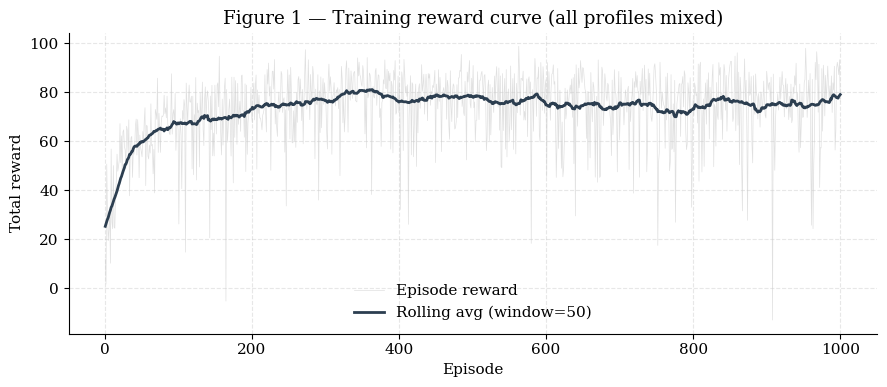

In [48]:
fig1, ax1 = plt.subplots(figsize=(9, 4))
episodes  = np.arange(1, len(all_rewards) + 1)
smoothed  = moving_average(all_rewards, window=50)

ax1.plot(episodes, all_rewards, color="#cccccc", linewidth=0.5, alpha=0.6, label="Episode reward")
ax1.plot(episodes, smoothed,    color="#2c3e50", linewidth=2.0,             label="Rolling avg (window=50)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total reward")
ax1.set_title("Figure 1 — Training reward curve (all profiles mixed)")
ax1.legend(frameon=False)
fig1.tight_layout()
fig1.savefig("fig1_training_curve.png", dpi=150)
plt.show()

### Figure 2 — Per-Profile Knowledge Over Training
Did the agent learn to help each learner type over time? One smoothed line per profile.

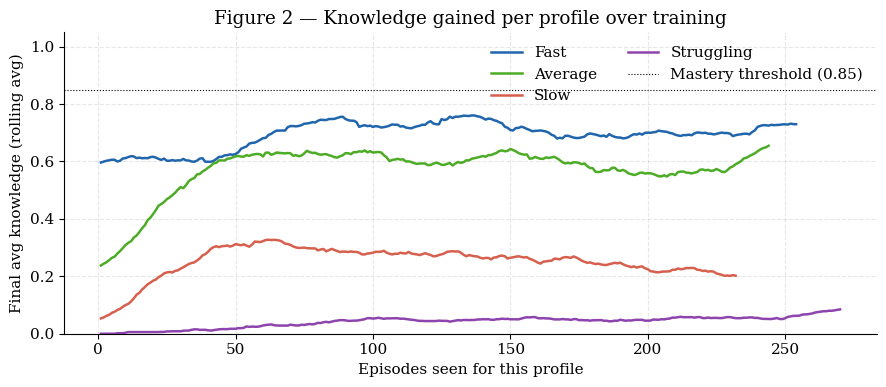

In [49]:
fig2, ax2 = plt.subplots(figsize=(9, 4))

for profile in PROFILE_ORDER:
    k_series = per_profile_know[profile]
    sm       = moving_average(k_series, window=30)
    ep_idx   = np.arange(1, len(k_series) + 1)
    ax2.plot(ep_idx, sm, color=PROFILE_COLORS[profile], linewidth=1.8, label=profile.capitalize())

ax2.axhline(MASTERY_THRESHOLD, color="black", linewidth=0.8,
            linestyle=":", label=f"Mastery threshold ({MASTERY_THRESHOLD})")
ax2.set_xlabel("Episodes seen for this profile")
ax2.set_ylabel("Final avg knowledge (rolling avg)")
ax2.set_title("Figure 2 — Knowledge gained per profile over training")
ax2.legend(frameon=False, ncol=2)
ax2.set_ylim(0, 1.05)
fig2.tight_layout()
fig2.savefig("fig2_per_profile_knowledge.png", dpi=150)
plt.show()

### Figure 3 — Evaluation Bar Chart
Clean results figure: what does the trained (greedy) agent achieve per profile?

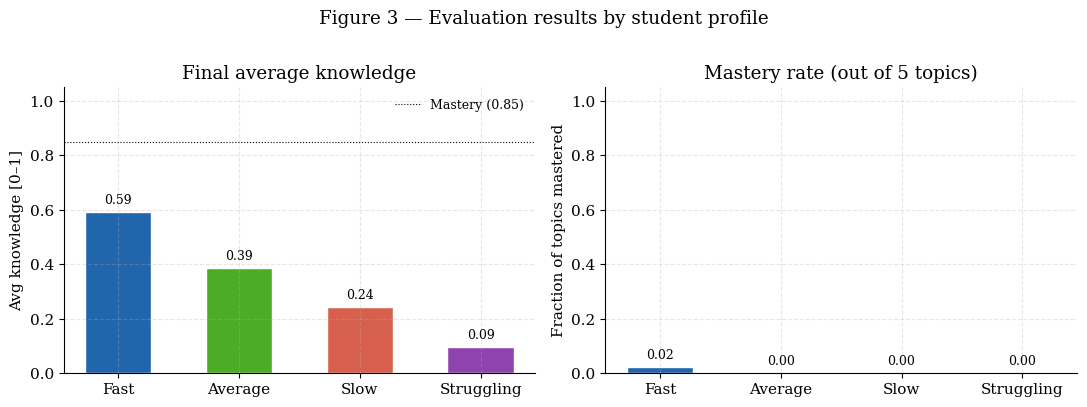

In [50]:
fig3, axes3 = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

labels = [p.capitalize() for p in PROFILE_ORDER]
colors = [PROFILE_COLORS[p] for p in PROFILE_ORDER]
x      = np.arange(len(PROFILE_ORDER))
width  = 0.55

# Left: final average knowledge
know_vals = [final_stats[p]["mean_knowledge"] for p in PROFILE_ORDER]
bars0 = axes3[0].bar(x, know_vals, width=width, color=colors, edgecolor="white")
axes3[0].axhline(MASTERY_THRESHOLD, color="black", linewidth=0.8,
                 linestyle=":", label=f"Mastery ({MASTERY_THRESHOLD})")
axes3[0].set_xticks(x)
axes3[0].set_xticklabels(labels)
axes3[0].set_ylabel("Avg knowledge [0\u20131]")
axes3[0].set_title("Final average knowledge")
axes3[0].set_ylim(0, 1.05)
axes3[0].legend(frameon=False, fontsize=9)
for bar, val in zip(bars0, know_vals):
    axes3[0].text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.02, f"{val:.2f}",
                  ha="center", va="bottom", fontsize=9)

# Right: mastery rate
mast_vals = [final_stats[p]["mastery_rate"] for p in PROFILE_ORDER]
bars1 = axes3[1].bar(x, mast_vals, width=width, color=colors, edgecolor="white")
axes3[1].set_xticks(x)
axes3[1].set_xticklabels(labels)
axes3[1].set_ylabel("Fraction of topics mastered")
axes3[1].set_title("Mastery rate (out of 5 topics)")
axes3[1].set_ylim(0, 1.05)
for bar, val in zip(bars1, mast_vals):
    axes3[1].text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.02, f"{val:.2f}",
                  ha="center", va="bottom", fontsize=9)

fig3.suptitle("Figure 3 \u2014 Evaluation results by student profile", y=1.01)
fig3.tight_layout()
fig3.savefig("fig3_eval_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

### Figure 4 — Step-by-Step Knowledge Trajectories
How does knowledge evolve during a single episode for each learner type?  
Thin lines = individual topics. Bold line = average across 5 topics.

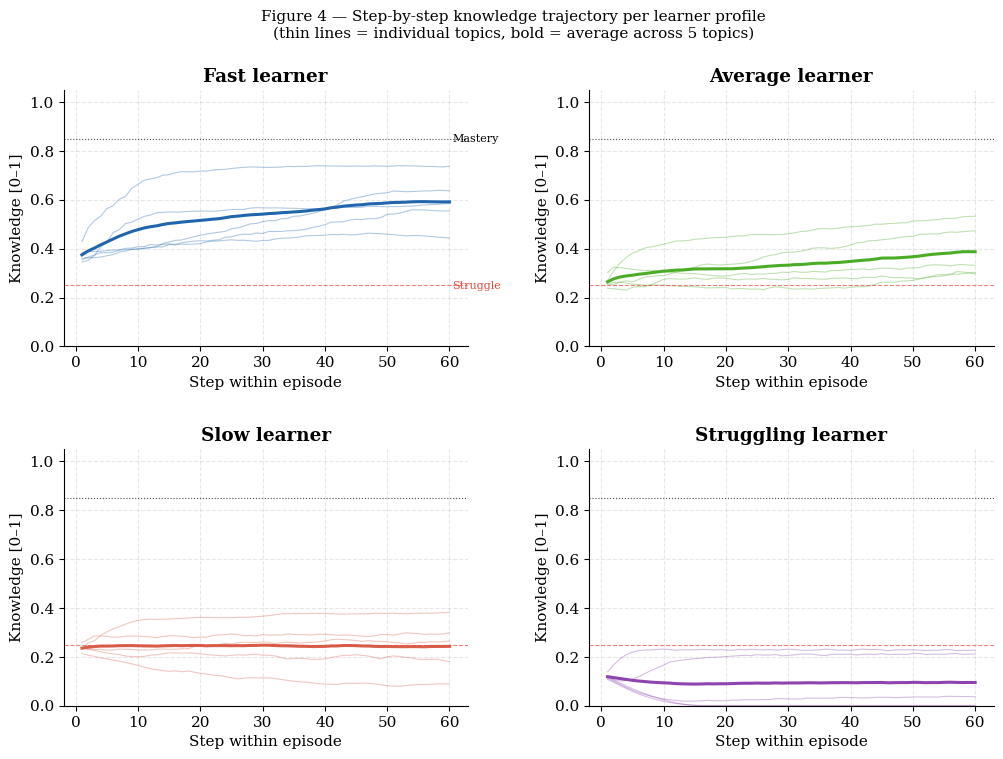

In [51]:
fig4 = plt.figure(figsize=(12, 8))
gs   = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.30)

for i, profile in enumerate(PROFILE_ORDER):
    ax      = fig4.add_subplot(gs[i // 2, i % 2])
    k_steps = step_knowledge[profile]   # (steps, NUM_TOPICS)
    avg_k   = k_steps.mean(axis=1)     # (steps,)
    steps_x = np.arange(1, len(avg_k) + 1)

    for t in range(NUM_TOPICS):
        ax.plot(steps_x, k_steps[:, t], linewidth=0.8, alpha=0.35,
                color=PROFILE_COLORS[profile])

    ax.plot(steps_x, avg_k, color=PROFILE_COLORS[profile],
            linewidth=2.2, label="Avg across topics")

    ax.axhline(MASTERY_THRESHOLD,  color="black",   linewidth=0.8, linestyle=":",  alpha=0.7)
    ax.axhline(STRUGGLE_THRESHOLD, color="#e74c3c", linewidth=0.8, linestyle="--", alpha=0.7)

    ax.set_title(f"{profile.capitalize()} learner", fontweight="bold")
    ax.set_xlabel("Step within episode")
    ax.set_ylabel("Knowledge [0\u20131]")
    ax.set_ylim(0, 1.05)

    if i == 0:
        ax.text(steps_x[-1] + 0.5, MASTERY_THRESHOLD,
                "Mastery",  va="center", fontsize=8)
        ax.text(steps_x[-1] + 0.5, STRUGGLE_THRESHOLD,
                "Struggle", va="center", fontsize=8, color="#e74c3c")

fig4.suptitle(
    "Figure 4 \u2014 Step-by-step knowledge trajectory per learner profile\n"
    "(thin lines = individual topics, bold = average across 5 topics)",
    fontsize=11
)
fig4.savefig("fig4_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 11. Results Summary

In [35]:
print("Final Evaluation Summary")
print("=" * 65)
print(f"{'Profile':<12} {'Avg Knowledge':>14} {'Mastery Rate':>13} {'Struggle Frac':>14}")
print("-" * 65)
for p in PROFILE_ORDER:
    s = final_stats[p]
    print(f"{p.capitalize():<12} {s['mean_knowledge']:>14.3f} "
          f"{s['mastery_rate']:>13.3f} {s['struggle_frac']:>14.3f}")
print("=" * 65)
print(f"\nOverall training reward (last 100 eps): {np.mean(all_rewards[-100:]):.2f}")
print(f"Peak rolling avg reward               : {moving_average(all_rewards, 50).max():.2f}")

Final Evaluation Summary
Profile       Avg Knowledge  Mastery Rate  Struggle Frac
-----------------------------------------------------------------
Fast                  0.605         0.128          0.125
Average               0.416         0.052          0.334
Slow                  0.336         0.000          0.438
Struggling            0.056         0.000          0.848

Overall training reward (last 100 eps): 80.31
Peak rolling avg reward               : 87.03
